# Cattle Hip-height measurement test data analysis report

In [376]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch
from itertools import cycle

# ---------- Config ----------
display_debug_table = True  # Whether to print progress output to console
OFFSET = 9  # Centimeters (eg. 20) to add/subtract from hip height, in case of false setup tags height
SCALE_FACTOR = 1.0  # Multiply all heights by this factor, in case of false input tags distance height (e.g., 100m instead of 1m)

# Global, reusable color palette for cattle IDs (extend/replace as you like)
CATTLE_PALETTE = [
    "#3B5B92",  # deep steel blue
    "#7A88CF",  # periwinkle
    "#4E9ACF",  # sky blue
    "#6B6BD6",  # indigo
    "#8C6BBE",  # muted violet
    "#2E6F8F",  # teal-blue
    "#6F76A6",  # slate lavender
    "#4093A5",  # cyan-teal
    "#555B8A",  # slate blue
    "#9A8CD9",  # soft lilac
]

MEAN_COLOR = "#D62728"

## 1. Data Retrieval

### 1.1 Corrected Data Format

Within data folder please ensure that 2 files existed (with exact name):
1. actual.csv (the actual measurement that gain from manually measure a cattle hip-height that can be done by tape measurement)
2. record.csv (the recorded data that gain from running the algorithm)

Within each files, please ensure that the following column with exact name exist
- **actual.csv**: 
* Each row represent the order in which cattle come in frame
* HipHeight
* cattle_id (optional)
- **record.csv**: (no need to worry as it's auto-generate from algorithm) 
* timestamp_iso (this would include auto or manual break which important to seperate cattle)
* hip_height_cm
* confidence
* frame_id (this would be useful when seperate by break is unreliale)
* cattle_id (optional)

*cattle_id is optional as the algorithm currently couldn't seperate a cattle correctly yet.

### 1.2 Dataframe retrieval and renaming

In [377]:
# --- Standardize and load actual.csv & record.csv from data/ --- #
# Usage:
#   1) Put your files at: data/actual.csv and data/record.csv
#   2) Run this cell
#   3) Use `actual_df` and `record_df` (timestamp stays as STRING)

DATA_DIR = Path("data")
ACTUAL_PATH = DATA_DIR / "actual.csv"
RECORD_PATH = DATA_DIR / "record.csv"

def _norm(s: str) -> str:
    """Normalize a header: lowercase, non-alnum -> underscore, collapse underscores."""
    s = s.strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def _find_matches(colmap, cols):
    """Map canonical name -> first matching original column (by normalized synonyms)."""
    norm2orig = {_norm(c): c for c in cols}
    out = {}
    for canon, synonyms in colmap.items():
        match = None
        for syn in synonyms:
            if _norm(syn) in norm2orig:
                match = norm2orig[_norm(syn)]
                break
        out[canon] = match
    return out

def _read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path)  # keep default inference; we'll coerce columns explicitly later
    # Drop unnamed empty columns
    drop_cols = [c for c in df.columns if _norm(c).startswith("unnamed")]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    return df

# Accepted header synonyms
ACTUAL_CANONICAL = {
    "order": ["order", "appearance_order", "est_order_in_video", "seq", "sequence", "index"],
    "cattle_id": ["cattle_id", "tag", "ear_tag", "animal_id", "cow_id"],
    "hip_height": [
        "HipHeight","hipheight","hip_height","height","hip_height_cm","hipheight_cm",
        "measured_height_cm","actual_height","actual_height_cm","height_cm",
        "tape_height","tape","tape_cm"
    ]
}

RECORD_CANONICAL = {
    "timestamp": ["timestamp","timestamp_iso","time_iso","datetime","datetime_iso"],
    "cattle_id": ["cattle_id","animal_id","cow_id","tag","ear_tag"],
    "hip_height": ["hip_height_cm","hipheight_cm","hip_height","height","height_cm"],
    "confidence": ["confidence","score","prob","p"],
    "frame_id": ["frame_id","frame","fid","frame_index"],
}

def load_actual_df(path: Path) -> pd.DataFrame:
    raw = _read_csv(path)
    matches = _find_matches(ACTUAL_CANONICAL, list(raw.columns))
    # Rename found columns to canonical names
    rename_map = {matches[k]: k for k in matches if matches[k] is not None}
    df = raw.rename(columns=rename_map)

    # Require hip_height; others optional
    if "hip_height" not in df.columns:
        raise ValueError(
            f"'hip_height' not found in {path.name}. "
            f"Accepted names include: {', '.join(ACTUAL_CANONICAL['hip_height'])}\n"
            f"Columns present: {list(raw.columns)}"
        )

    # ---- Types & ordering ----
    df["hip_height"] = pd.to_numeric(df["hip_height"], errors="coerce")

    if "order" in df.columns:
        df["order"] = pd.to_numeric(df["order"], errors="coerce")
        df = df.sort_values("order", kind="stable")

    # ---- cattle_id handling ----
    if "cattle_id" in df.columns:
        # try to coerce to Int64; if all NA after coercion, fall back to row-order IDs
        cid = pd.to_numeric(df["cattle_id"], errors="coerce").astype("Int64")
        if cid.notna().any():
            df["cattle_id"] = cid
        else:
            df = df.reset_index(drop=True)
            df["cattle_id"] = pd.Series(range(1, len(df) + 1), dtype="Int64")
    else:
        # no cattle_id provided → assign by row order (1..N)
        df = df.reset_index(drop=True)
        df["cattle_id"] = pd.Series(range(1, len(df) + 1), dtype="Int64")

    # Optional: put key columns first (helps downstream merges/printing)
    cols = list(df.columns)
    for k in ["cattle_id", "hip_height", "order"]:
        if k in cols:
            cols.insert(0, cols.pop(cols.index(k)))
    df = df[cols]

    return df

def load_record_df(path: Path) -> pd.DataFrame:
    raw = _read_csv(path)
    matches = _find_matches(RECORD_CANONICAL, list(raw.columns))
    rename_map = {matches[k]: k for k in matches if matches[k] is not None}
    df = raw.rename(columns=rename_map)

    # Require timestamp & hip_height
    missing = [c for c in ["timestamp", "hip_height"] if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing required columns in {path.name}: {missing}\n"
            f"Accepted names → timestamp: {RECORD_CANONICAL['timestamp']} | "
            f"hip_height: {RECORD_CANONICAL['hip_height']}\n"
            f"Columns present: {list(raw.columns)}"
        )

    # Keep timestamp as STRING (no datetime parsing here)
    df["timestamp"] = df["timestamp"].astype(str)

    # --- Numeric coercions ---
    df["hip_height"] = pd.to_numeric(df["hip_height"], errors="coerce")
    if "confidence" in df.columns:
        df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")
    if "frame_id" in df.columns:
        df["frame_id"] = pd.to_numeric(df["frame_id"], errors="coerce").astype("Int64")
    if "cattle_id" in df.columns:
        # keep as string labels if present
        df["cattle_id"] = pd.to_numeric(df["cattle_id"], errors="coerce").astype("Int64").astype("string")

    # --- Apply scale/offset to hip_height ---
    # Preserve original
    df["hip_height_raw"] = df["hip_height"]

    # OFFSET is defined in *meters*; hip_height is in *cm* → convert OFFSET to cm
    offset = float(OFFSET)
    scale = float(SCALE_FACTOR)

    # Adjusted height: (raw * SCALE_FACTOR) + OFFSET(cm)
    df["hip_height"] = (df["hip_height_raw"] * scale) + offset

    if display_debug_table:
        n = df["hip_height_raw"].notna().sum()
        print(f"[load_record_df] Applied SCALE_FACTOR={scale} and OFFSET={OFFSET} m "
              f"(={offset:.1f} cm) to {n} rows of hip_height.")

    return df

# ---- Load both ----
actual_df = load_actual_df(ACTUAL_PATH)
record_df = load_record_df(RECORD_PATH)

if display_debug_table:
    print("Loaded actual_df columns:", list(actual_df.columns))
    display(actual_df.head()) # Peek
    print("Loaded record_df columns:", list(record_df.columns))
    display(record_df.head()) # Peek
    print(f"actual_df rows: {len(actual_df)}, record_df rows: {len(record_df)}")

[load_record_df] Applied SCALE_FACTOR=1.0 and OFFSET=9 m (=9.0 cm) to 574 rows of hip_height.
Loaded actual_df columns: ['hip_height', 'cattle_id']


,hip_height,cattle_id
0,120,1
1,120,2
2,120,3


Loaded record_df columns: ['timestamp', 'cattle_id', 'hip_height', 'confidence', 'frame_id', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'hip_height_raw']


,timestamp,cattle_id,hip_height,confidence,frame_id,bbox_x1,bbox_y1,bbox_x2,bbox_y2,hip_height_raw
0,2025-10-17 14:18:08,1,121.03,0.153,208,522.0,290.0,1548.0,939.0,112.03
1,NEW_CATTLE_AUTO,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
2,2025-10-17 14:18:09,2,114.99,0.532,214,795.0,324.0,1601.0,941.0,105.99
3,2025-10-17 14:18:09,2,115.17,0.269,215,587.0,334.0,1594.0,943.0,106.17
4,2025-10-17 14:18:09,2,113.99,0.378,216,600.0,326.0,1595.0,929.0,104.99


actual_df rows: 3, record_df rows: 597


## 2. Data Cleaning

### 2.1 Seperate record cattle to matched the number of cattle in actual

Since our auto cattle seperators are not always accurate. Even if client were to do it manually sometimes he might do it incorrectly. So, I implemented the fallback in this report to be able to seperate the cattle in record.csv. So, that it's matched what the actual cattle numbers record in actual.csv

In [378]:
num_cattle = len(actual_df)
seperate_success = False

#### 2.1.1 Seperate using auto seperator

In [379]:
# Auto-separate cattle by "NEW_CATTLE_AUTO" markers and assign cattle_id 1..K

# Pre-reqs:
# - num_cattle = len(actual_df)
# - record_df already loaded
# - record_df includes either "timestamp_iso" or "timestamp"
# - marker rows have "NEW_CATTLE_AUTO" in timestamp column and NaNs elsewhere

# pick the right timestamp column
ts_col = "timestamp_iso" if "timestamp_iso" in record_df.columns else (
    "timestamp" if "timestamp" in record_df.columns else None
)
if ts_col is None:
    raise KeyError("record_df must contain 'timestamp_iso' or 'timestamp' column for auto separation.")

# rows that are explicit separators
auto_break = record_df[ts_col].astype(str).eq("NEW_CATTLE_AUTO")

# measurements present?
measure_mask = record_df["hip_height"].notna()

# cattle_id starts at 1 and increments at each separator
cattle_id_series = auto_break.cumsum() + 1

# how many cattle detected (exclude the separator rows themselves)
n_detected = int(cattle_id_series[measure_mask].max()) if measure_mask.any() else 0

# Default: not successful
seperate_success = False

if n_detected == num_cattle and n_detected > 0:
    # assign new cattle_id only to measurement rows; leave separator rows as <NA>
    record_df.loc[measure_mask, "cattle_id"] = cattle_id_series[measure_mask].astype("Int64")
    record_df.loc[~measure_mask, "cattle_id"] = pd.NA
    seperate_success = True
    print(f"✅ Auto separator success: detected {n_detected} cattle, matches expected {num_cattle}.")
else:
    print(f"❌ Auto separator not accurate: detected {n_detected}, expected {num_cattle}. Moving to next separator...")


❌ Auto separator not accurate: detected 14, expected 3. Moving to next separator...


#### 2.1.2 Seperate using manual seperator

In [380]:
# Manual-only separation using NEW_CATTLE_MANUAL markers
# Pre-reqs: record_df, num_cattle, and pandas as pd

if not seperate_success:
    # 1) Pick the timestamp column
    ts_col = "timestamp_iso" if "timestamp_iso" in record_df.columns else (
        "timestamp" if "timestamp" in record_df.columns else None
    )
    if ts_col is None:
        raise KeyError("record_df must contain 'timestamp_iso' or 'timestamp'")

    ts = record_df[ts_col].astype(str)

    # 2) Identify manual marker rows
    manual_raw = ts.eq("NEW_CATTLE_MANUAL")

    # 3) De-bounce consecutive manual markers: keep only the first in any run
    manual_boundary = manual_raw & ~manual_raw.shift(fill_value=False)

    # 4) Only assign IDs to measurement rows (ignore marker rows)
    measure_mask = record_df["hip_height"].notna()

    # 5) Build cattle_id sequence by cumulative sum of boundaries, start at 1
    cattle_seq = 1 + manual_boundary.cumsum()

    # Rebase so the first *measurement* row is cattle_id == 1 (handles leading markers)
    if measure_mask.any():
        first_id = int(cattle_seq[measure_mask].iloc[0])
        cattle_seq = cattle_seq - (first_id - 1)

    # 6) Count detected cattle from measurement rows only
    n_detected = int(cattle_seq[measure_mask].max()) if measure_mask.any() else 0

    # 7) Apply if matches expected; otherwise, leave as-is
    seperate_success = False
    if n_detected == num_cattle and n_detected > 0:
        record_df.loc[measure_mask, "cattle_id"] = cattle_seq[measure_mask].astype("Int64")
        record_df.loc[~measure_mask, "cattle_id"] = pd.NA  # keep marker rows as NA
        seperate_success = True
        print(f"✅ Manual separator success: detected {n_detected} cattle, matches expected {num_cattle}.")
    else:
        print(f"❌ Manual separator not accurate: detected {n_detected}, expected {num_cattle}. Moving to next strategy...")


❌ Manual separator not accurate: detected 5, expected 3. Moving to next strategy...


#### 2.1.3 Seperate using auto timestamp interval

In [381]:
# --- Timestamp-gap based separation (auto-pick threshold to match num_cattle) ---

# Early return if separation already done
if not seperate_success:
    # Choose timestamp column (string). We won't overwrite it.
    ts_col = "timestamp_iso" if "timestamp_iso" in record_df.columns else (
        "timestamp" if "timestamp" in record_df.columns else None
    )
    if ts_col is None:
        raise KeyError("record_df must contain 'timestamp_iso' or 'timestamp'")

    # 1) Build a view with only measurement rows; drop marker rows like NEW_CATTLE_*
    meas = record_df.copy()
    meas["_ts_raw"] = meas[ts_col].astype(str)
    meas["_is_marker"] = meas["_ts_raw"].str.startswith("NEW_CATTLE_")
    meas = meas[meas["hip_height"].notna() & (~meas["_is_marker"])].copy()

    if meas.empty:
        seperate_success = False
        print("❌ Timestamp-gap separator: no measurement rows available.")
        raise SystemExit

    # 2) Parse a parallel datetime column (original strings remain untouched)
    meas["ts_parsed"] = pd.to_datetime(meas["_ts_raw"], errors="coerce")

    # Sort by parsed timestamp (stable sort keeps original order where equal/NaT)
    meas = meas.sort_values(["ts_parsed"]).reset_index()

    # 3) Compute consecutive time gaps (seconds)
    dt = meas["ts_parsed"].diff()
    gap_sec = dt.dt.total_seconds().fillna(0)

    # Negative/NaT gaps (out-of-order or parse failures) are treated as 0
    gap_sec = np.where(np.isfinite(gap_sec) & (gap_sec > 0), gap_sec, 0.0).astype(float)
    meas["gap_sec"] = gap_sec

    # 4) Candidate thresholds = unique positive gap values (plus 0 as baseline)
    unique_gaps = sorted(set(g for g in gap_sec if g > 0))
    candidates = [0.0] + unique_gaps

    def segments_for_threshold(th):
        # A new segment starts when gap > th
        # Segments count = 1 + number of gaps strictly greater than threshold
        return 1 + int((meas["gap_sec"] > th).sum())

    # 5) Pick threshold:
    #    Prefer the *smallest* th that yields exactly num_cattle.
    #    If none match, pick th that minimizes |segments - num_cattle| (tie → smaller th).
    best_th = None
    best_seg = None

    # First, try to find exact match
    for th in candidates:
        s = segments_for_threshold(th)
        if s == num_cattle:
            best_th = th
            best_seg = s
            break

    # If no exact match, choose closest
    if best_th is None:
        diffs = [(abs(segments_for_threshold(th) - num_cattle), th) for th in candidates]
        diffs.sort(key=lambda x: (x[0], x[1]))  # minimize diff, then threshold
        best_th = diffs[0][1]
        best_seg = segments_for_threshold(best_th)

    # 6) Build cattle_id from chosen threshold
    boundary = meas["gap_sec"] > best_th
    cattle_seq = 1 + boundary.cumsum()  # starts at 1, bumps at each big gap
    meas["cattle_id_new"] = cattle_seq.astype("Int64")

    # 7) Write back only to measurement rows in the original record_df
    seperate_success = False

    # Build a candidate Int64 series aligned to record_df (no assignment yet)
    candidate_ids = pd.Series(pd.NA, index=record_df.index, dtype="Int64")
    candidate_ids.loc[meas["index"]] = meas["cattle_id_new"]  # <- proposed IDs

    if best_seg == num_cattle and best_seg > 0:
        # Ensure target column exists and is Int64, then commit the candidate
        if "cattle_id" not in record_df.columns or record_df["cattle_id"].dtype != "Int64":
            record_df["cattle_id"] = pd.Series(pd.NA, index=record_df.index, dtype="Int64")
        record_df["cattle_id"] = candidate_ids
        seperate_success = True
        print(f"✅ Timestamp-gap separator success: detected {best_seg} cattle "
            f"with threshold {best_th:.3f}s (matches expected {num_cattle}).")
    else:
        # Do NOT modify record_df on failure
        print(f"❌ Timestamp-gap best fit: detected {best_seg} cattle with threshold {best_th:.3f}s "
            f"(expected {num_cattle}). No changes applied.")
        # Optional: keep `candidate_ids` in memory for inspection
        # display(pd.DataFrame({"candidate_cattle_id": candidate_ids}).dropna())

    # Optional quick summary (uncomment to view)
    # display(
    #     record_df[record_df["hip_height"].notna()]
    #       .groupby("cattle_id", dropna=True)
    #       .agg(n=("hip_height","size"),
    #            start_time=(ts_col,"first"),
    #            end_time=(ts_col,"last"),
    #            med_height=("hip_height","median"))
    #       .sort_index()
    # )

✅ Timestamp-gap separator success: detected 3 cattle with threshold 5.000s (matches expected 3).


#### 2.1.4 Seperate using manual frame seperator
This is the least ideal solution, but if all the above fail. We had to do this. Please input the frame number when you think it's new cattle that's entering the frame (please compare the timestamp_iso in record.csv file with actual video so you know when the first cattle appear that got detected)

Or it would be a lot easier, if client trying to press b button multiple times. Then at least we can track a row where "NEW_CATTLE_MANUAL" appear, and make some sense into what frame that it got seperated.

In [382]:
NEW_CATTLE_FRAME = []
# for example: NEW_CATTLE_FRAME = [150, 450, 780, ...]

In [383]:
# --- Manual frame-based separation ---
# Pre-reqs:
#   - record_df has columns: 'hip_height' and 'frame_id' (numeric/int-like)
#   - num_cattle = len(actual_df)
#   - NEW_CATTLE_FRAME = [ ... ]  # e.g., [150, 450, 780, ...], each is first frame of a new cow

# Early return if separation already done
if not seperate_success:
    # 0) Guards
    if "frame_id" not in record_df.columns:
        raise KeyError("record_df must contain a 'frame_id' column for manual frame separation.")
    if "hip_height" not in record_df.columns:
        raise KeyError("record_df must contain a 'hip_height' column.")

    # 1) Normalize inputs
    #    - ensure frame_id is integer-like (nullable Int64 okay)
    record_df["frame_id"] = pd.to_numeric(record_df["frame_id"], errors="coerce").astype("Int64")

    #    - sanitize the provided marks: unique, drop NaNs, cast to plain ints, sort
    marks = pd.Series(NEW_CATTLE_FRAME).dropna().astype(int).sort_values().unique().tolist()

    if len(marks) == 0:
        print("❌ No manual frame marks provided (NEW_CATTLE_FRAME empty). No changes applied.")
        seperate_success = False
        raise SystemExit

    # 2) Work on measurement rows only (ignore marker/empty rows)
    meas = record_df.loc[record_df["hip_height"].notna()].copy()
    if meas.empty:
        print("❌ No measurement rows available. No changes applied.")
        seperate_success = False
        raise SystemExit

    # 3) Convert marks to boundaries using >= (so exact match not required)
    meas = record_df.loc[record_df["hip_height"].notna()].copy()
    meas = meas.dropna(subset=["frame_id"]).copy()
    meas["frame_id"] = pd.to_numeric(meas["frame_id"], errors="coerce").astype("Int64")
    meas = meas.dropna(subset=["frame_id"]).copy()
    meas["frame_id"] = meas["frame_id"].astype(int)

    # Sort by frame_id, keep original index for writing back later
    meas = meas.sort_values("frame_id").reset_index()  # original index now in meas["index"]
    frame_vals = meas["frame_id"].to_numpy()

    # keep only marks within the range of measurement frames
    marks_arr = pd.Series(NEW_CATTLE_FRAME, dtype="Int64").dropna().astype(int).sort_values().unique()
    in_range = (marks_arr >= frame_vals.min()) & (marks_arr <= frame_vals.max())
    valid_marks = marks_arr[in_range]

    # map each mark to the first measurement row with frame_id >= mark
    idx_positions = np.searchsorted(frame_vals, valid_marks, side="left")
    idx_positions = np.clip(idx_positions, 0, len(frame_vals)-1)
    idx_positions = np.unique(idx_positions)  # collapse duplicates

    # 4) Boundary vector (True at those positions)
    boundary = np.zeros(len(meas), dtype=bool)
    boundary[idx_positions] = True

    # 5) Create 1-based cattle IDs and rebase so the FIRST measurement row is ID=1
    cattle_seq = 1 + boundary.cumsum()
    first_id = int(cattle_seq[0])
    if first_id != 1:
        cattle_seq = cattle_seq - (first_id - 1)

    meas["cattle_id_new"] = pd.Series(cattle_seq, dtype="Int64")

    # 6) Count detected cattle from measurement rows
    n_detected = int(meas["cattle_id_new"].max()) if len(meas) else 0

    # 7) Commit only on success (leave record_df untouched otherwise)
    seperate_success = False
    if n_detected == num_cattle and n_detected > 0:
        if "cattle_id" not in record_df.columns or record_df["cattle_id"].dtype != "Int64":
            record_df["cattle_id"] = pd.Series(pd.NA, index=record_df.index, dtype="Int64")
        record_df.loc[meas["index"], "cattle_id"] = meas["cattle_id_new"]
        seperate_success = True
        print(f"✅ Manual frame separator success: detected {n_detected} cattle (matches expected {num_cattle}).")
    else:
        print(f"❌ Manual frame separator not accurate: detected {n_detected}, expected {num_cattle}. No changes applied.")

    # Optional: preview what would have been assigned
    # preview = pd.DataFrame({"frame_id": meas["frame_id"], "candidate_cattle_id": meas["cattle_id_new"]})
    # display(preview.head(20))


### 2.2 Clear low confidence (and empty height) row

Low confidence row could cause by several issues such as:
1. The cattle is not fully within the frame (could be obstruct by human walking by as well)
2. False detection (eg. that frame it might detect human as a cattle)
3. Unintended cattle got detected (maybe some unwanted cattle that's in the background got detected)

However, this also depends on the environmental factors that could impact the confidence as well such as lighting, low-contrast between cattle coat colour and background, etc. 

So, please **take a good look at the recorded CSV or graph below before decide the confidence threshold below**:

#### 2.2.1 See each cattle confidence histogram
Please have a look here before deciding what confidence threshold should be selected

In [384]:
# ----- Config -----
BINS = np.arange(0, 101, 1)   # 5%-wide bins
X_SPACE = 5  # X-axis spacing in the plot

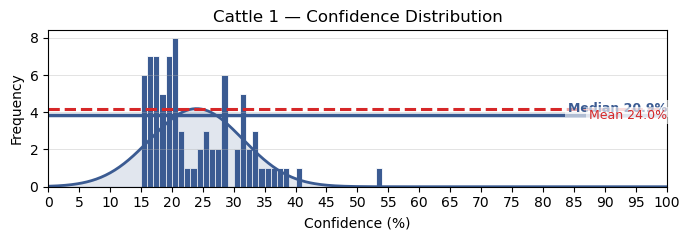

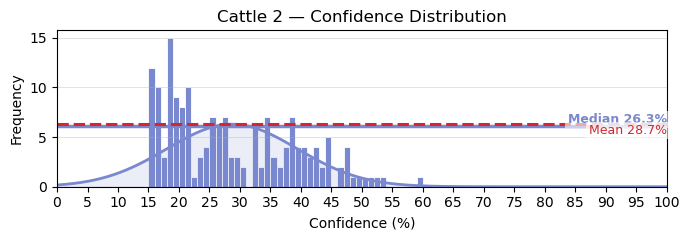

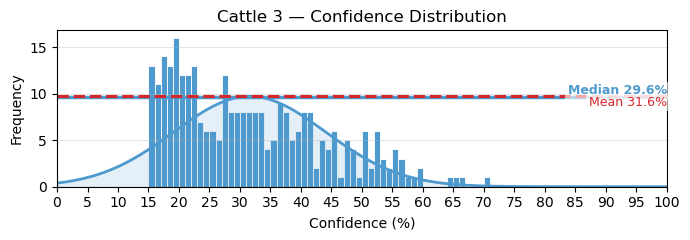

In [385]:
# === One histogram per cattle (confidence in 0–100%) ===
# ----- Prep -----
if "confidence" not in record_df.columns or "cattle_id" not in record_df.columns:
    raise KeyError("record_df must contain 'confidence' and 'cattle_id' columns.")

df = record_df.copy()
df["confidence_pct"] = pd.to_numeric(df["confidence"], errors="coerce") * 100.0
df = df.dropna(subset=["cattle_id", "confidence_pct"]).copy()
df["confidence_pct"] = df["confidence_pct"].clip(0, 100)

# stable order of cattle ids
unique_ids = pd.unique(df["cattle_id"])
cid_to_color = {cid: col for cid, col in zip(unique_ids, cycle(CATTLE_PALETTE))}

def label_for(cid):
    try:
        return f"Cattle {int(cid)}"
    except Exception:
        return f"Cattle {str(cid)}"

# ----- Plot: one figure per cattle -----
for cid in unique_ids:
    sub = df.loc[df["cattle_id"] == cid, "confidence_pct"].astype(float)
    if sub.empty:
        continue

    color = cid_to_color[cid]
    plt.figure(figsize=(7, 2.5))

    # Histogram (frequency)
    counts, bin_edges, _ = plt.hist(
        sub, bins=BINS, edgecolor="white", linewidth=0.6, color=color
    )

    ax = plt.gca()
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_locator(MultipleLocator(X_SPACE))
    ax.set_ylim(bottom=0)
    plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)

    # --- Normal curve (outline + translucent fill), scaled to frequency ---
    mu = float(sub.mean())
    sigma = float(sub.std(ddof=1)) if len(sub) > 1 else 0.0
    if sigma > 0:
        x = np.linspace(0, 100, 400)
        pdf = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
        bin_width = np.diff(bin_edges)[0]
        y = pdf * len(sub) * bin_width  # scale to histogram counts

        # outline
        plt.plot(x, y, color=color, linewidth=2.0)
        # translucent fill
        plt.fill_between(x, y, 0, color=color, alpha=0.15)

        # heights at mean/median for horizontal lines
        med = float(sub.median())
        y_med = np.interp(med, x, y)
        y_mean = np.interp(mu,  x, y)
    else:
        med = float(sub.median())
        # if no curve (sigma=0), draw lines at a small fixed height for visibility
        y_med = y_mean = max(ax.get_ylim()[1] * 0.15, 1.0)

    ymax = ax.get_ylim()[1]

    # --- Horizontal lines + labels ---
    # Median: palette color, bold
    ax.axhline(y_med, color=color, linewidth=2.5)
    ax.text(
        100, y_med, f"Median {med:.1f}%", color=color,
        ha="right", va="bottom", fontsize=9, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.5)
    )

    # Mean: bright red, dashed
    ax.axhline(y_mean, color=MEAN_COLOR, linewidth=2.2, linestyle="--")
    ax.text(
        100, y_mean, f"Mean {mu:.1f}%", color=MEAN_COLOR,
        ha="right", va="top", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.5)
    )

    # Titles/labels
    plt.title(f"{label_for(cid)} — Confidence Distribution")
    plt.xlabel("Confidence (%)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


#### 2.2.2 Selecting confidence threshold and remove low confidence rows

In [386]:
CONFIDENCE_THRESHOLD = 0.25 # e.g., 0.25 = 25%

In [387]:
# Filter record_df by confidence and valid hip_height

before = len(record_df)

# Keep rows with hip_height present
mask_height = record_df["hip_height"].notna()

# Keep rows with confidence >= threshold (if confidence column exists)
if "confidence" in record_df.columns:
    # .ge handles NaN -> False after fillna
    mask_conf = record_df["confidence"].ge(CONFIDENCE_THRESHOLD).fillna(False)
else:
    # If there's no confidence column, keep everything on this criterion
    mask_conf = True

record_df = record_df[mask_height & mask_conf].copy()

after = len(record_df)
print(f"Filtered rows: {before - after} (kept {after} of {before})")

if display_debug_table:
    display(record_df.head()) # Peek


Filtered rows: 281 (kept 316 of 597)


,timestamp,cattle_id,hip_height,confidence,frame_id,bbox_x1,bbox_y1,bbox_x2,bbox_y2,hip_height_raw
2,2025-10-17 14:18:09,1,114.99,0.532,214,795.0,324.0,1601.0,941.0,105.99
3,2025-10-17 14:18:09,1,115.17,0.269,215,587.0,334.0,1594.0,943.0,106.17
4,2025-10-17 14:18:09,1,113.99,0.378,216,600.0,326.0,1595.0,929.0,104.99
6,2025-10-17 14:18:09,1,114.12,0.403,219,616.0,276.0,1530.0,957.0,105.12
7,2025-10-17 14:18:09,1,116.21,0.321,220,595.0,295.0,1630.0,940.0,107.21


#### 2.2.3 Confidence interval after thresholding

In [388]:
# ----- Config -----
BINS = np.arange(0, 101, 5)   # 5%-wide bins
X_SPACE = 10  # X-axis spacing in the plot

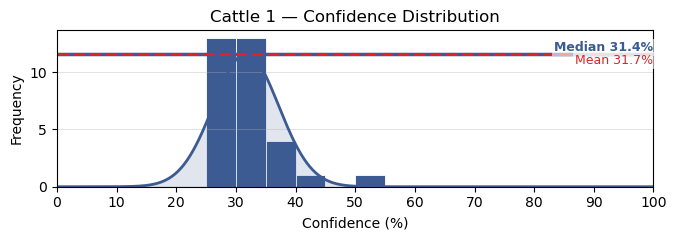

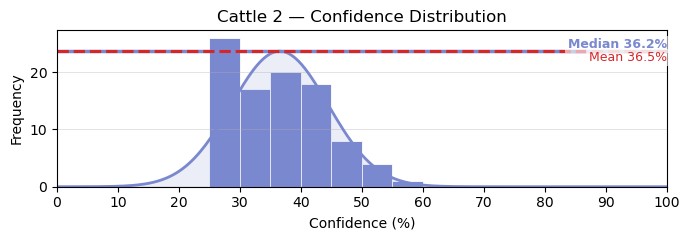

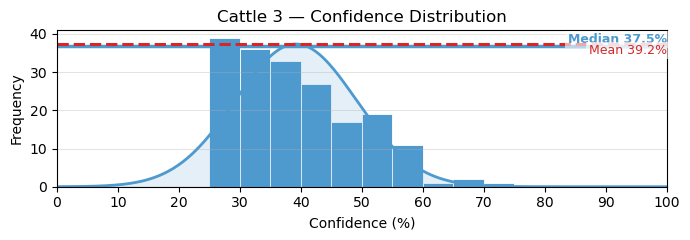

In [389]:
# ----- Prep -----
if "confidence" not in record_df.columns or "cattle_id" not in record_df.columns:
    raise KeyError("record_df must contain 'confidence' and 'cattle_id' columns.")

df = record_df.copy()
df["confidence_pct"] = pd.to_numeric(df["confidence"], errors="coerce") * 100.0
df = df.dropna(subset=["cattle_id", "confidence_pct"]).copy()
df["confidence_pct"] = df["confidence_pct"].clip(0, 100)

# stable order of cattle ids
unique_ids = pd.unique(df["cattle_id"])
cid_to_color = {cid: col for cid, col in zip(unique_ids, cycle(CATTLE_PALETTE))}

def label_for(cid):
    try:
        return f"Cattle {int(cid)}"
    except Exception:
        return f"Cattle {str(cid)}"

# ----- Plot: one figure per cattle -----
for cid in unique_ids:
    sub = df.loc[df["cattle_id"] == cid, "confidence_pct"].astype(float)
    if sub.empty:
        continue

    color = cid_to_color[cid]
    plt.figure(figsize=(7, 2.5))

    # Histogram (frequency)
    counts, bin_edges, _ = plt.hist(
        sub, bins=BINS, edgecolor="white", linewidth=0.6, color=color
    )

    ax = plt.gca()
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_locator(MultipleLocator(X_SPACE))
    ax.set_ylim(bottom=0)
    plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)

    # --- Normal curve (outline + translucent fill), scaled to frequency ---
    mu = float(sub.mean())
    sigma = float(sub.std(ddof=1)) if len(sub) > 1 else 0.0
    if sigma > 0:
        x = np.linspace(0, 100, 400)
        pdf = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
        bin_width = np.diff(bin_edges)[0]
        y = pdf * len(sub) * bin_width  # scale to histogram counts

        # outline
        plt.plot(x, y, color=color, linewidth=2.0)
        # translucent fill
        plt.fill_between(x, y, 0, color=color, alpha=0.15)

        # heights at mean/median for horizontal lines
        med = float(sub.median())
        y_med = np.interp(med, x, y)
        y_mean = np.interp(mu,  x, y)
    else:
        med = float(sub.median())
        # if no curve (sigma=0), draw lines at a small fixed height for visibility
        y_med = y_mean = max(ax.get_ylim()[1] * 0.15, 1.0)

    ymax = ax.get_ylim()[1]

    # --- Horizontal lines + labels ---
    # Median: palette color, bold
    ax.axhline(y_med, color=color, linewidth=2.5)
    ax.text(
        100, y_med, f"Median {med:.1f}%", color=color,
        ha="right", va="bottom", fontsize=9, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.5)
    )

    # Mean: bright red, dashed
    ax.axhline(y_mean, color=MEAN_COLOR, linewidth=2.2, linestyle="--")
    ax.text(
        100, y_mean, f"Mean {mu:.1f}%", color=MEAN_COLOR,
        ha="right", va="top", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.5)
    )

    # Titles/labels
    plt.title(f"{label_for(cid)} — Confidence Distribution")
    plt.xlabel("Confidence (%)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 3. Data Analysis

### 3.1 Accuracy against actual data
In this section, we basically just use pure accuracy against the actual measurement

In [390]:
# --- CONFIG ---
# Threshold colors
OK_COLOR   = "#2CA02C"  # green
WARN_COLOR = "#FF7F0E"  # orange
BAD_COLOR  = MEAN_COLOR  # red

#### 3.1.1 Table

In [391]:
# --- Build "actual" series indexed by cattle_id 1..K ---
act = actual_df.copy()

if "cattle_id" in act.columns:
    act_id = pd.to_numeric(act["cattle_id"], errors="coerce").astype("Int64")
elif "order" in act.columns:
    act_id = pd.to_numeric(act["order"], errors="coerce").astype("Int64")
else:
    act_id = pd.Series(range(1, len(act) + 1), index=act.index, dtype="Int64")

act_vals = pd.to_numeric(act["hip_height"], errors="coerce")
actual_series = pd.Series(act_vals.values, index=act_id.values).dropna()
# if duplicates, keep first actual per cattle (or change to .mean())
actual_series = actual_series[~actual_series.index.duplicated(keep="first")]

# --- Observed mean from record_df by cattle_id ---
rec = record_df.copy()
rec = rec[rec["hip_height"].notna() & rec["cattle_id"].notna()]
rec["cattle_id"] = pd.to_numeric(rec["cattle_id"], errors="coerce").astype("Int64")

mean_series = rec.groupby("cattle_id", dropna=True)["hip_height"].mean()

# --- MAE over frames per cattle (vs actual) ---
# join frame-level hip_height with actual per cattle, then take mean absolute error per cattle
rec_with_actual = rec.join(actual_series.rename("actual"), on="cattle_id")
rec_with_actual["abs_err"] = (rec_with_actual["hip_height"] - rec_with_actual["actual"]).abs()
mae_series = rec_with_actual.groupby("cattle_id", dropna=True)["abs_err"].mean()

# --- Columns: union of all cattle we have (sorted) ---
cattle_ids = sorted(set(actual_series.index.dropna().astype(int)) |
                    set(mean_series.index.dropna().astype(int)) |
                    set(mae_series.index.dropna().astype(int)))

if not cattle_ids:
    raise ValueError("No cattle IDs found in either actual_df or record_df after cleaning.")

# --- Assemble table with one column per cattle ---
table = pd.DataFrame(index=[
    "Cattle No.",
    "Actual measurement (cm)",
    "Recorded average (cm)",
    "Absolute error (cm)",
    "MAE over frames (cm)",
])

# Fill columns
for cid in cattle_ids:
    actual = float(actual_series.get(cid, np.nan)) if cid in actual_series.index else np.nan
    mean_obs = float(mean_series.get(cid, np.nan)) if cid in mean_series.index else np.nan
    abs_err = abs(mean_obs - actual) if np.isfinite(actual) and np.isfinite(mean_obs) else np.nan
    mae = float(mae_series.get(cid, np.nan)) if cid in mae_series.index else np.nan

    col_name = f"Cattle {cid}"
    table.loc["Cattle No.", col_name] = cid
    table.loc["Actual measurement (cm)", col_name] = actual
    table.loc["Recorded average (cm)", col_name] = mean_obs
    table.loc["Absolute error (cm)", col_name] = abs_err
    table.loc["MAE over frames (cm)", col_name] = mae

# --- Nicely format (1 decimal) and display ---
def _fmt(x):
    try:
        if pd.isna(x):
            return ""
        return f"{float(x):.1f}"
    except Exception:
        return str(x)

table_formatted = table.map(_fmt)

# --- Styler: color the error rows' TEXT; keep 1-decimal formatting ---
def _err_text_style(v):
    try:
        x = float(v)
    except Exception:
        return ""
    if np.isnan(x): return ""
    if x <= 3:      return f"color: {OK_COLOR}; font-weight: 600;"
    if x <= 5:      return f"color: {WARN_COLOR}; font-weight: 600;"
    return f"color: {BAD_COLOR}; font-weight: 700;"

styled = (
    table.copy()
         .astype("float", errors="ignore")
         .style
         .format("{:.1f}", na_rep="")
         .map(_err_text_style, subset=pd.IndexSlice[
             ["Absolute error (cm)", "MAE over frames (cm)"], :
         ])
)

display(styled)


,Cattle 1,Cattle 2,Cattle 3
Cattle No.,1.0,2.0,3.0
Actual measurement (cm),120.0,120.0,120.0
Recorded average (cm),120.0,121.4,124.4
Absolute error (cm),0.0,1.4,4.4
MAE over frames (cm),7.5,2.3,7.3


#### 3.1.2 Comparative bar plot

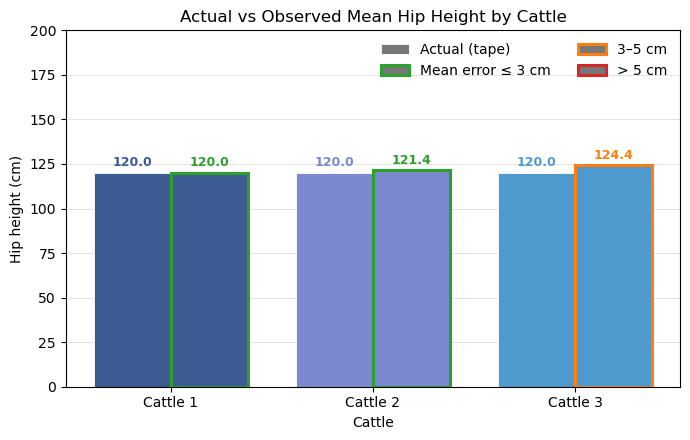

In [392]:
# --- Build "actual" series indexed by cattle_id 1..K ---
act = actual_df.copy()
if "cattle_id" in act.columns:
    act_id = pd.to_numeric(act["cattle_id"], errors="coerce").astype("Int64")
elif "order" in act.columns:
    act_id = pd.to_numeric(act["order"], errors="coerce").astype("Int64")
else:
    # implicit order 1..N in current order
    act_id = pd.Series(range(1, len(act) + 1), index=act.index, dtype="Int64")

act_vals = pd.to_numeric(act["hip_height"], errors="coerce")
actual_series = pd.Series(act_vals.values, index=act_id.values).dropna()
# If duplicates in actual, take the first (or you can use .mean())
actual_series = actual_series[~actual_series.index.duplicated(keep="first")]

# --- Build "observed mean" from record_df by cattle_id ---
rec = record_df.copy()
rec = rec[rec["hip_height"].notna() & rec["cattle_id"].notna()]
rec["cattle_id"] = pd.to_numeric(rec["cattle_id"], errors="coerce").astype("Int64")
mean_series = rec.groupby("cattle_id", dropna=True)["hip_height"].mean()

# --- X axis herd (union of cattle seen in either side), sorted 1..K ---
cattle_ids = sorted(set(actual_series.index.dropna().astype(int))
                    | set(mean_series.index.dropna().astype(int)))
if not cattle_ids:
    raise ValueError("No cattle IDs found in either actual_df or record_df after cleaning.")

# --- Bar data aligned to cattle_ids ---
actual_heights = [actual_series.get(cid, np.nan) for cid in cattle_ids]
observed_means = [mean_series.get(cid, np.nan) for cid in cattle_ids]

# --- Colors: per-cattle palette for actual bars ---
colors_actual = [CATTLE_PALETTE[(i % len(CATTLE_PALETTE))] for i, _ in enumerate(cattle_ids)]

def diff_color(actual, mean):
    if np.isnan(actual) or np.isnan(mean):
        return "#888888"  # fallback for missing data
    d = abs(mean - actual)
    if d <= 3:
        return OK_COLOR
    elif d <= 5:  # 3 < d <= 5  (e.g., 4.5 -> orange)
        return WARN_COLOR
    else:         # d > 5
        return BAD_COLOR

x = np.arange(len(cattle_ids))
width = 0.38

# Y ceiling w/ headroom so labels don’t clip
all_vals = np.array(actual_heights + observed_means, dtype=float)
base_ceiling = max(180.0, float(np.nanmax(all_vals)) if all_vals.size else 0.0)
y_ceiling = np.ceil((base_ceiling * 1.10) / 5.0) * 5.0

plt.figure(figsize=(max(7, 0.8 * len(cattle_ids) + 3), 4.5))

# Actual bars (palette fill + white outline)
bars_actual = plt.bar(
    x - width/2, actual_heights, width=width,
    color=colors_actual, edgecolor="white", linewidth=0.6, zorder=2
)

# Mean bars (palette fill + *per-bar* outline color by error)
mean_outline_colors = [diff_color(a, m) for a, m in zip(actual_heights, observed_means)]
mean_linewidths = [2.2] * len(cattle_ids)

bars_mean = plt.bar(
    x + width/2, observed_means, width=width,
    color=colors_actual, edgecolor=mean_outline_colors, linewidth=mean_linewidths, zorder=2
)

# Axes & grid
plt.ylabel("Hip height (cm)")
plt.xlabel("Cattle")
plt.title("Actual vs Observed Mean Hip Height by Cattle")
plt.xticks(x, [f"Cattle {cid}" for cid in cattle_ids])
plt.ylim(0, y_ceiling)
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5, zorder=1)

# Legend (Actual + mean error bands)
legend_patches = [
    Patch(facecolor="#777777", edgecolor="white", linewidth=0.6, label="Actual (tape)"),
    Patch(facecolor="#777777", edgecolor=OK_COLOR,   linewidth=2.2, label="Mean error ≤ 3 cm"),
    Patch(facecolor="#777777", edgecolor=WARN_COLOR, linewidth=2.2, label="3–5 cm"),
    Patch(facecolor="#777777", edgecolor=BAD_COLOR,  linewidth=2.2, label="> 5 cm"),
]
plt.legend(handles=legend_patches, frameon=False, ncol=2)

# Annotations (after ylim is set)
def annotate_bars_per_color(bars, colors):
    for b, c in zip(bars, colors):
        h = b.get_height()
        if np.isnan(h):
            continue
        x_center = b.get_x() + b.get_width() / 2
        y_text = h + max(0.5, 0.01 * y_ceiling)
        plt.text(
            x_center, y_text, f"{h:.1f}",
            ha="center", va="bottom", fontsize=9, color=c, fontweight="bold",
            zorder=3,
        )

# Actual labels in palette color
annotate_bars_per_color(bars_actual, colors_actual)

# Mean labels in the same per-bar outline color (green/orange/red)
annotate_bars_per_color(bars_mean, mean_outline_colors)

plt.tight_layout()
plt.show()


#### 3.1.3 Residual plot (MAE error spread for each frame)

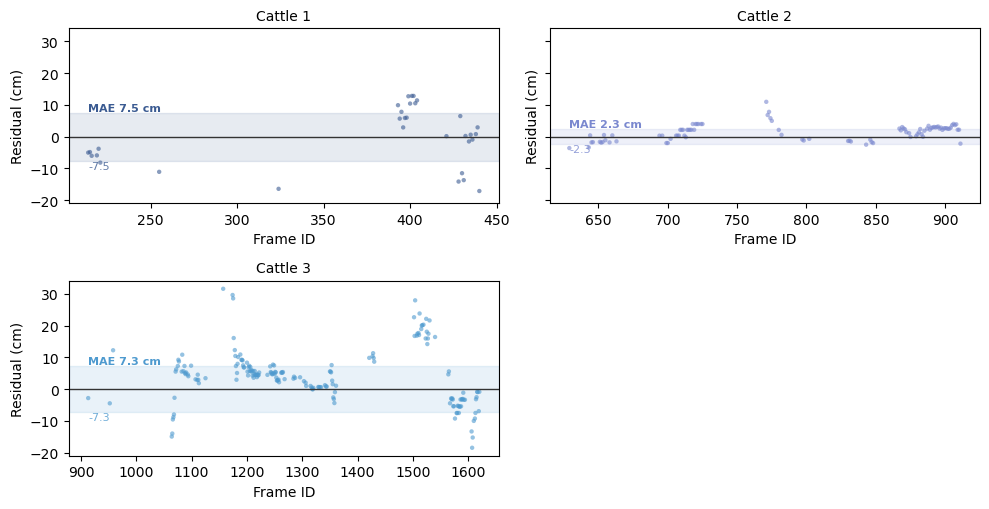

In [393]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Build residual frame-level data (you already computed rec_with_actual)
res = rec_with_actual.dropna(subset=["hip_height","actual","frame_id","cattle_id"]).copy()
res["residual"] = res["hip_height"] - res["actual"]

ids = sorted(res["cattle_id"].dropna().astype(int).unique())
n = len(ids)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 2.6*rows), squeeze=False, sharey=True)
for ax, cid in zip(axes.flat, ids):
    g = res[res["cattle_id"] == cid]
    if g.empty:
        ax.axis("off"); continue

    color = cid_to_color.get(cid, "#666")
    ax.scatter(g["frame_id"], g["residual"], s=10, alpha=0.6, color=color, edgecolors="none")
    ax.axhline(0, color="#333", linewidth=1)

    mae = float(mae_series.get(cid, np.nan))
    if np.isfinite(mae):
        ax.axhspan(-mae, mae, color=color, alpha=0.12)
        ax.text(g["frame_id"].min(), mae, f"MAE {mae:.1f} cm",
                va="bottom", ha="left", fontsize=8, color=color, fontweight="bold")
        ax.text(g["frame_id"].min(), -mae, f"-{mae:.1f}",
                va="top", ha="left", fontsize=8, color=color, alpha=0.8)

    ax.set_title(f"Cattle {cid}", fontsize=10)
    ax.set_xlabel("Frame ID")
    ax.set_ylabel("Residual (cm)")

# Hide unused axes if any
for j in range(n, rows*cols):
    axes.flat[j].axis("off")

plt.tight_layout()
plt.show()

### 3.2 Does the confidence impact accuracy?

In [394]:
# Build merged frame with actual + per-frame error and confidence %
rec = record_df.copy()
rec = rec[rec["hip_height"].notna() & rec["cattle_id"].notna()].copy()
rec["cattle_id"] = pd.to_numeric(rec["cattle_id"], errors="coerce").astype("Int64")
actual_map = (actual_df.assign(
    cid = pd.to_numeric(actual_df.get("cattle_id", actual_df.get("order")), errors="coerce")
)[["cid","hip_height"]].dropna().drop_duplicates("cid").set_index("cid")["hip_height"])
rec["actual"] = rec["cattle_id"].map(actual_map)
rec = rec.dropna(subset=["actual","confidence"]).copy()
rec["err"] = rec["hip_height"] - rec["actual"]
rec["abs_err"] = rec["err"].abs()
rec["conf_pct"] = (pd.to_numeric(rec["confidence"], errors="coerce") * 100).clip(0,100)


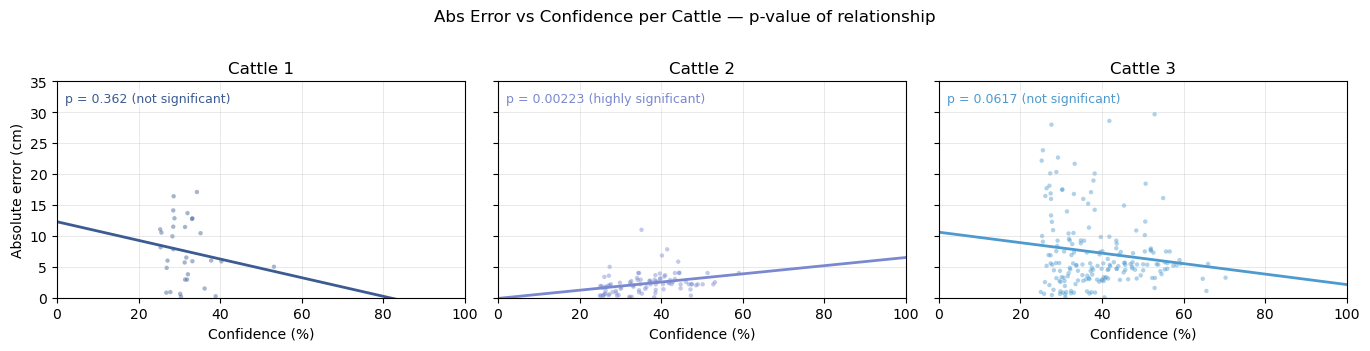

In [395]:
# Optional: choose correlation type for reporting
USE_SPEARMAN = False  # set True for rank-based (robust to nonlinearity)

# Helper: p-value -> stars
def sig_stars(p):
    if p < 0.001: return "extremely significant"
    if p < 0.01:  return "highly significant"
    if p < 0.05:  return "significant"
    return "not significant"

# Expect `rec` to have ['cattle_id','conf_pct','abs_err']
unique_ids = sorted(pd.unique(rec["cattle_id"].dropna().astype(int)))
if 'cid_to_color' not in globals() or not isinstance(globals().get('cid_to_color'), dict):
    cid_to_color = {cid: CATTLE_PALETTE[i % len(CATTLE_PALETTE)] for i, cid in enumerate(unique_ids)}

# Shared y limit for comparability
ymax = float(np.nanmax(rec["abs_err"])) if len(rec) else 0.0
ymax = np.ceil((ymax * 1.10) / 5.0) * 5.0 if ymax > 0 else 5.0

cols = 3
rows = math.ceil(len(unique_ids) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 3.4*rows), squeeze=False, sharex=True, sharey=True)

# Try to import scipy tests
try:
    from scipy.stats import linregress, pearsonr, spearmanr
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

for ax, cid in zip(axes.flat, unique_ids):
    g = rec.loc[rec["cattle_id"] == cid, ["conf_pct", "abs_err"]].dropna()
    color = cid_to_color.get(cid, "#555B8A")

    # scatter
    ax.scatter(g["conf_pct"], g["abs_err"], s=10, alpha=0.45, color=color, edgecolors="none")

    p_text = "insufficient data"
    if len(g) >= 3 and HAVE_SCIPY:
        x = g["conf_pct"].to_numpy()
        y = g["abs_err"].to_numpy()

        # Fit straight line (for visual context)
        b, a = np.polyfit(x, y, 1)  # slope, intercept
        xx = np.array([0.0, 100.0]); yy = a + b * xx
        ax.plot(xx, yy, linewidth=2.0, color=color)

        # Statistical test
        if USE_SPEARMAN:
            r, p = spearmanr(x, y, nan_policy="omit")
            stat_name = "Spearman ρ"
        else:
            # regress p-value (slope ≠ 0) gives the same inference as Pearson r test
            slope, intercept, r_value, p, stderr = linregress(x, y)
            r = r_value
            stat_name = "slope≠0 (linreg)"

        p_text = f"p = {p:.3g} ({sig_stars(p)})"

        # Optional: also show direction via r
        # ax.text(0.02, 0.82, f"r = {r:.2f}", transform=ax.transAxes, ha="left", va="top",
        #         fontsize=9, color=color)

    ax.text(0.02, 0.95, p_text, transform=ax.transAxes, ha="left", va="top",
            fontsize=9, color=color, bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1.5))

    ax.set_title(f"Cattle {cid}")
    ax.grid(True, which="both", axis="both", linewidth=0.5, alpha=0.4)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, ymax)

# Hide extras
for k in range(len(unique_ids), rows*cols):
    axes.flat[k].axis("off")

# Shared labels
fig.suptitle("Abs Error vs Confidence per Cattle — p-value of relationship", y=1.02, fontsize=12)
for ax in axes[-1, :]:
    ax.set_xlabel("Confidence (%)")
for r in range(rows):
    axes[r, 0].set_ylabel("Absolute error (cm)")

plt.tight_layout()
plt.show()


**Note**:
1. If the graph going downward and stating "significant", "highly significant", or "extremely significant". It means that the more confidence the algorithm is, the accuracy is better because it had less error for each higher confidence measurements.
2. If the graph is a straight line or labelled as "not significant". It means that the confidence value doesn't impact the accuracy of the measurement
1. If the graph going upward and stating "significant", "highly significant", or "extremely significant". It means that the more confidence the algorithm is, the accuracy is worse because it had more error for each higher confidence measurements.

### 3.3 Take confidence into account when comparing the accuracy

In general, we assume would always assume that. Higher confidence frame, would result in better accuracy. It could be true or false, depends on the graph that you saw in section 3.2.

If you believe that the above assumption is **true**. We will proceed with the weighted measurement comparison. Where we value higher confidence frame result more than less confidence frame result. Instead of just averaging the whole observations and treat all measurements equally.

In [396]:
# === Confidence weighting config ===
# record_df['confidence'] is expected in [0..1]. We turn it into weights w >= 0.

WEIGHT_MODE   = "power"   # "linear" | "power" | "cutoff"
GAMMA         = 2.0       # only for mode="power": w = conf ** GAMMA  (γ>1 favors high confidence)
MIN_CONF_CUT  = 0.0       # only for mode="cutoff": keep frames with conf >= MIN_CONF_CUT (else weight=0)
EPS            = 1e-9     # tiny epsilon to avoid div-by-zero

def confidence_to_weight(conf: pd.Series) -> pd.Series:
    conf = pd.to_numeric(conf, errors="coerce").clip(lower=0, upper=1)
    if WEIGHT_MODE == "linear":
        w = conf
    elif WEIGHT_MODE == "power":
        w = conf.pow(GAMMA)
    elif WEIGHT_MODE == "cutoff":
        w = (conf >= MIN_CONF_CUT).astype(float)
    else:
        raise ValueError(f"Unknown WEIGHT_MODE: {WEIGHT_MODE}")
    # keep NaNs as 0 weights
    w = w.fillna(0.0)
    return w


#### 3.3.1 Table (with new weighted measurement)

In [397]:
# --- Build "actual" series indexed by cattle_id 1..K (same as §3.1) ---
act = actual_df.copy()
if "cattle_id" in act.columns:
    act_id = pd.to_numeric(act["cattle_id"], errors="coerce").astype("Int64")
elif "order" in act.columns:
    act_id = pd.to_numeric(act["order"], errors="coerce").astype("Int64")
else:
    act_id = pd.Series(range(1, len(act) + 1), index=act.index, dtype="Int64")

act_vals = pd.to_numeric(act["hip_height"], errors="coerce")
actual_series = pd.Series(act_vals.values, index=act_id.values).dropna()
actual_series = actual_series[~actual_series.index.duplicated(keep="first")]

# --- Frame-level data with weights ---
rec = record_df.copy()
rec = rec[rec["hip_height"].notna() & rec["cattle_id"].notna()].copy()
rec["cattle_id"]  = pd.to_numeric(rec["cattle_id"], errors="coerce").astype("Int64")
rec["hip_height"] = pd.to_numeric(rec["hip_height"], errors="coerce")

# weights from confidence
rec["w"] = confidence_to_weight(rec["confidence"])

# attach actual per cattle, compute abs error
rec = rec.join(actual_series.rename("actual"), on="cattle_id")
rec["abs_err"] = (rec["hip_height"] - rec["actual"]).abs()

# --- Weighted aggregates per cattle ---
grp = rec.groupby("cattle_id", dropna=True, as_index=True)

# per-cattle sums
sum_w         = grp["w"].sum().rename("sum_w")
sum_w_h       = (rec["w"] * rec["hip_height"]).groupby(rec["cattle_id"]).sum().rename("sum_w_h")
sum_w_abs_err = (rec["w"] * rec["abs_err"]).groupby(rec["cattle_id"]).sum().rename("sum_w_abs_err")

# weighted mean height & weighted MAE
weighted_mean = (sum_w_h / (sum_w + EPS)).rename("weighted_mean")
weighted_mae  = (sum_w_abs_err / (sum_w + EPS)).rename("weighted_mae")

# diagnostics (optional but useful)
n_frames   = grp.size().rename("N")
eff_n      = ((sum_w**2) / (grp["w"].apply(lambda s: (s**2).sum()) + EPS)).rename("N_eff")  # Kish effective N

# --- Assemble table like §3.1 but weighted ---
cattle_ids = sorted(set(actual_series.index.dropna().astype(int))
                    | set(weighted_mean.index.dropna().astype(int))
                    | set(weighted_mae.index.dropna().astype(int)))

table_w = pd.DataFrame(index=[
    "Cattle No.",
    "Actual measurement (cm)",
    "Weighted average (cm)",
    "Absolute error (cm)",           # |weighted_mean - actual|
    "Weighted MAE over frames (cm)", # mean(|error|) weighted by confidence
    "Frames (N)",
    "Effective N (Kish)",
])

for cid in cattle_ids:
    actual  = float(actual_series.get(cid, np.nan)) if cid in actual_series.index else np.nan
    wmean   = float(weighted_mean.get(cid, np.nan)) if cid in weighted_mean.index else np.nan
    wmae    = float(weighted_mae.get(cid, np.nan)) if cid in weighted_mae.index else np.nan
    abs_err = abs(wmean - actual) if np.isfinite(actual) and np.isfinite(wmean) else np.nan
    N       = int(n_frames.get(cid, np.nan)) if cid in n_frames.index else np.nan
    Neff    = float(eff_n.get(cid, np.nan)) if cid in eff_n.index else np.nan

    col = f"Cattle {cid}"
    table_w.loc["Cattle No.", col]                 = cid
    table_w.loc["Actual measurement (cm)", col]    = actual
    table_w.loc["Weighted average (cm)", col]      = wmean
    table_w.loc["Absolute error (cm)", col]        = abs_err
    table_w.loc["Weighted MAE over frames (cm)", col] = wmae
    table_w.loc["Frames (N)", col]                 = N
    table_w.loc["Effective N (Kish)", col]         = Neff

# display with coloring thresholds you already use
def _fmt1(x):
    try:
        return "" if pd.isna(x) else f"{float(x):.1f}"
    except Exception:
        return str(x)

styled_w = (
    table_w.copy()
           .astype("float", errors="ignore")
           .style
           .format("{:.1f}", na_rep="")
           .map(
               lambda v: (
                   "" if (pd.isna(v) or not np.isfinite(v)) else
                   (f"color: {OK_COLOR}; font-weight: 600;" if v <= 3 else
                    f"color: {WARN_COLOR}; font-weight: 600;" if v <= 5 else
                    f"color: {BAD_COLOR}; font-weight: 700;")
               ),
               subset=pd.IndexSlice[["Absolute error (cm)", "Weighted MAE over frames (cm)"], :]
           )
)

display(styled_w)


,Cattle 1,Cattle 2,Cattle 3
Cattle No.,1.0,2.0,3.0
Actual measurement (cm),120.0,120.0,120.0
Weighted average (cm),119.8,121.9,123.6
Absolute error (cm),0.2,1.9,3.6
Weighted MAE over frames (cm),7.2,2.5,6.9
Frames (N),32.0,94.0,186.0
Effective N (Kish),27.7,79.2,146.4


**Note**:

Effective N is “how many equally useful frames you really have” after you give bigger weight to some frames and tiny weight to others. Imagine 10 students doing a group assignment. If 2 students do almost all the works and the other 8 barely help, it feels like you only had about 2–3 real helpers. That “about 2–3” is the Effective N.

Quick examples:
- If all 5 frames help the same amount → it feels like 5 real frames (Effective N ≈ 5).
- If you have 5 frames but 1 frame gets most of the weight and the other 4 barely count → it feels like ~1 real frame (Effective N ≈ 1).
- With 400 frames where high-confidence frames get most of the weight, you might end up with Effective N = 70. So your estimate is as stable as if you had 70 equally good frames.

Why it matters: weighting can improve accuracy (by trusting better frames), but your “real sample size” shrinks. Effective N tells you how much it shrank.

#### 3.3.2 Comparative bar plot (using weighted measurement)

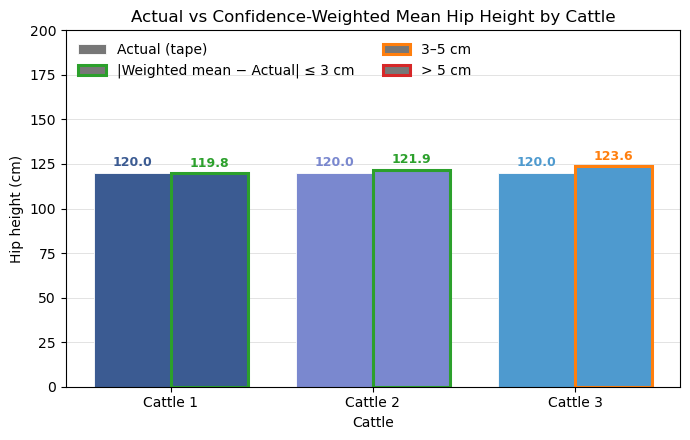

In [398]:
# Data aligned to cattle_ids
actual_heights   = [actual_series.get(cid, np.nan)   for cid in cattle_ids]
weighted_means   = [weighted_mean.get(cid, np.nan)   for cid in cattle_ids]

# Colors: per-cattle palette for both bars; outline on weighted bar shows error band (green/orange/red)
colors_actual = [CATTLE_PALETTE[i % len(CATTLE_PALETTE)] for i, _ in enumerate(cattle_ids)]

def diff_color(a, b):
    if np.isnan(a) or np.isnan(b): return "#888888"
    d = abs(b - a)
    if d <= 3: return OK_COLOR
    if d <= 5: return WARN_COLOR
    return BAD_COLOR

outline_colors = [diff_color(a, m) for a, m in zip(actual_heights, weighted_means)]

x = np.arange(len(cattle_ids))
width = 0.38

# y ceiling rule (≥180 unless data higher), with headroom
all_vals = np.array(actual_heights + weighted_means, dtype=float)
base_ceiling = max(180.0, float(np.nanmax(all_vals)) if all_vals.size else 0.0)
y_ceiling = np.ceil((base_ceiling * 1.10) / 5.0) * 5.0

plt.figure(figsize=(max(7, 0.8 * len(cattle_ids) + 3), 4.5))

bars_actual = plt.bar(
    x - width/2, actual_heights, width=width,
    color=colors_actual, edgecolor="white", linewidth=0.6, zorder=2, label="Actual (tape)"
)

bars_weighted = plt.bar(
    x + width/2, weighted_means, width=width,
    color=colors_actual, edgecolor=outline_colors, linewidth=2.2, zorder=2, label="Weighted mean"
)

plt.ylabel("Hip height (cm)")
plt.xlabel("Cattle")
plt.title("Actual vs Confidence-Weighted Mean Hip Height by Cattle")
plt.xticks(x, [f"Cattle {cid}" for cid in cattle_ids])
plt.ylim(0, y_ceiling)
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5, zorder=1)

# Legend explaining outline = error band
legend_items = [
    Patch(facecolor="#777777", edgecolor="white", linewidth=0.6, label="Actual (tape)"),
    Patch(facecolor="#777777", edgecolor=OK_COLOR,   linewidth=2.2, label="|Weighted mean − Actual| ≤ 3 cm"),
    Patch(facecolor="#777777", edgecolor=WARN_COLOR, linewidth=2.2, label="3–5 cm"),
    Patch(facecolor="#777777", edgecolor=BAD_COLOR,  linewidth=2.2, label="> 5 cm"),
]
plt.legend(handles=legend_items, frameon=False, ncol=2, loc="upper left")

# Label values (actual in palette color, weighted in outline color)
def annotate(bars, colors):
    for b, c in zip(bars, colors):
        h = b.get_height()
        if np.isnan(h): continue
        x_center = b.get_x() + b.get_width()/2
        y_text = h + max(0.5, 0.01 * y_ceiling)
        plt.text(x_center, y_text, f"{h:.1f}", ha="center", va="bottom",
                 fontsize=9, color=c, fontweight="bold", zorder=3)

annotate(bars_actual,  colors_actual)
annotate(bars_weighted, outline_colors)

plt.tight_layout()
plt.show()
